#### Importing ML Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import joblib

In [2]:
# Loading ML Data
ml_data = pd.read_csv("data/data_ml_model.csv")

In [4]:
# Splitting Data to training and testing data
X = ml_data.drop(["price", "flight"], axis=1)
y = ml_data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.copy()
X_test = X_test.copy()

In [5]:
# OneHot Endcoding for Nominal Features
onehot_encoder = OneHotEncoder(drop="first", sparse_output=False)

object_cols = X.select_dtypes("object").columns
X_train_encoded = onehot_encoder.fit_transform(X_train[object_cols])
feature_names = onehot_encoder.get_feature_names_out(object_cols)
X_train[feature_names] = X_train_encoded

X_test_encoded = onehot_encoder.transform(X_test[object_cols])
X_test[feature_names] = X_test_encoded

In [ ]:
# Scaling "days_left" feature
standard_scaler = StandardScaler()
X_train["days_left"] = standard_scaler.fit_transform(X_train[["days_left"]])
X_test["days_left"] = standard_scaler.transform(X_test[["days_left"]])

In [7]:
# Dropping Object Columns
object_cols = X.select_dtypes("object").columns
X_train.drop(object_cols, axis=1, inplace=True)
X_test.drop(object_cols, axis=1, inplace=True)

In [8]:
# Plot function to visualize the regression model
def visual_regression(model_name, y_test, y_pred):
    plt.style.use("ggplot")
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color="#7933ff", label="Predicted VS Actual")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2, label="Best Fitted Line")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{model_name}: Actual vs Predicted Prices")
    plt.legend()
    plt.grid(True)
    plt.savefig(f"imgs/{model_name}.png")
    plt.show()

In [ ]:
# Initializing ML Models
ml_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_jobs=-1),
    "XGBoost": XGBRegressor(n_jobs=-1)
}

In [17]:
RandomForest_Hyperparameters = {
    "n_estimators": [100, 300, 500],
    "max_depth": range(10, 50),
    "min_samples_split": range(2, 10, 2),
    "min_samples_leaf":range(3, 11, 2),
    "max_features": [1.0, "sqrt", "log2"]
}

In [18]:
XGBoost_Hyperparameters = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.1, 0.05, 0.01, 0.001],
    "max_depth": range(3, 14, 2),
    "min_child_weight":range(1, 11, 2),
    "gamma": [0.0, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}


Linear Regression:

Training Score: 0.8800170718688687
R2 Score: 0.8791990284184755
Mean Squared Error (MSE): 62270759.48017305
Cross Validation Score: 0.9151421904852783




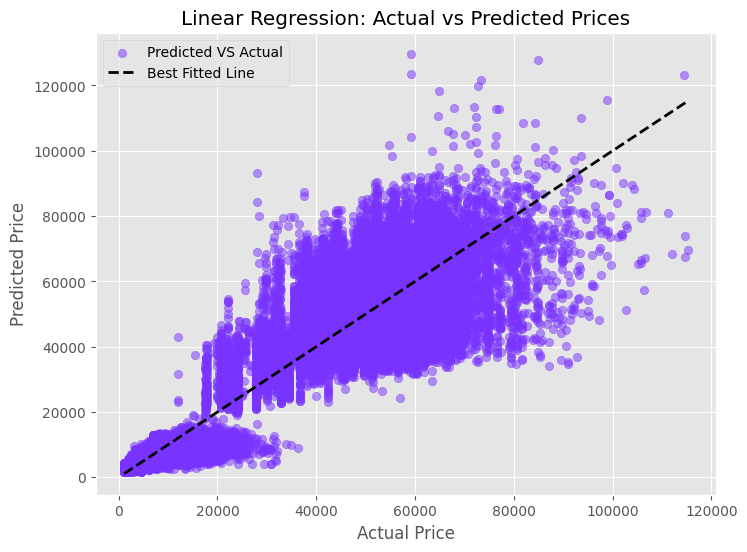


Random Forest:

Training Score: 0.9924704116439733
R2 Score: 0.9858251513731355
Mean Squared Error (MSE): 7306883.197670685
Cross Validation Score: 0.9839299435440058




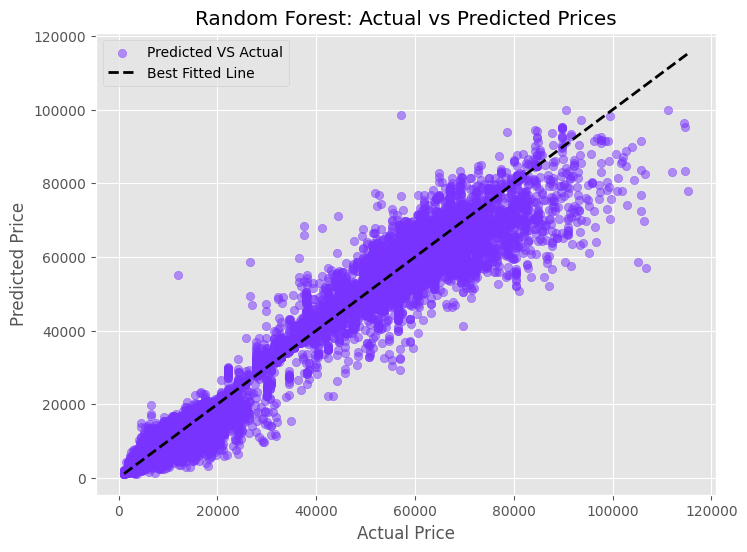


XGBoost:

Training Score: 0.9913328677413064
R2 Score: 0.9866661479551494
Mean Squared Error (MSE): 6873364.367510577
Cross Validation Score: 0.9849245077949128




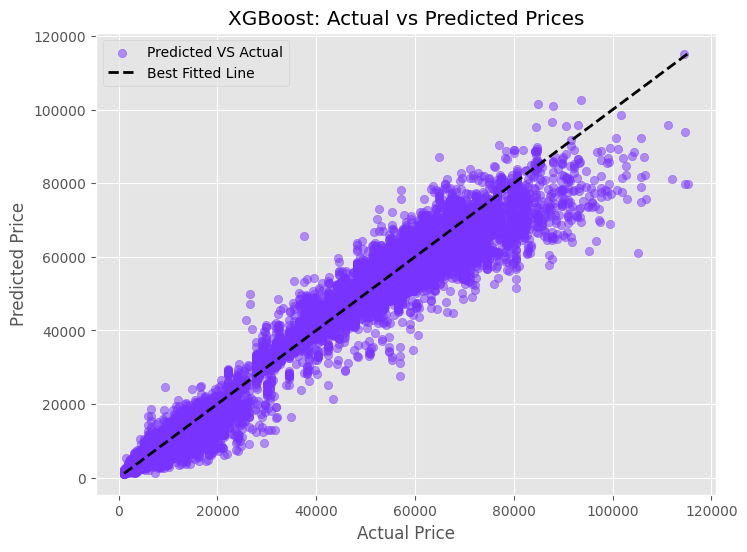

In [ ]:
# Training ML Models
for name, model in ml_models.items():
    print(f"\n{name}:\n")

    if name == "Random Forest":
        random_search_cv = RandomizedSearchCV(estimator=model, param_distributions=RandomForest_Hyperparameters, n_iter=10, cv=3, random_state=42, n_jobs=-1)
        random_search_cv.fit(X_train, y_train)

        model = random_search_cv.best_estimator_
        print(f"Best Model: {model}")
    
    if name == "XGBoost":
        random_search_cv = RandomizedSearchCV(estimator=model, param_distributions=XGBoost_Hyperparameters, n_iter=20, cv=3, random_state=42, n_jobs=-1)
        random_search_cv.fit(X_train, y_train)

        model = random_search_cv.best_estimator_
        print(f"Best Model: {model}")

    model.fit(X_train, y_train)

    k_fold = KFold(n_splits=5, shuffle=True)
    cross_validation = cross_val_score(model, X_train, y_train, cv=k_fold)

    y_pred = model.predict(X_test)

    y_pred = y_pred.copy()
    y_test = y_test.copy()

    y_pred = np.expm1(y_pred)
    y_true = np.expm1(y_test)

    y_train_pred = np.expm1(model.predict(X_train))
    y_train_origin = np.expm1(y_train)

    print(f"Training Score: {r2_score(y_train_origin, y_train_pred)}")
    print(f"R2 Score: {r2_score(y_true, y_pred)}")
    print(f"Mean Squared Error (MSE): {mean_squared_error(y_true, y_pred)}")
    print(f"Cross Validation Score: {np.mean(cross_validation)}")
    print("\n")

    # Visualize the model
    visual_regression(name, y_true, y_pred)

    # Saving the model
    joblib.dump(model, f"models/{name}.pkl")

In [ ]:
joblib.dump(onehot_encoder, "models/onehot_encoder.pkl")
joblib.dump(standard_scaler, "models/standard_scaler.pkl")

['models/standard_scaler.pkl']